In [144]:
import sys, os 
import geopandas as gpd 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint
import matplotlib.pyplot as plt
from boruta import BorutaPy

In [145]:
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)

In [146]:
class Runner:
    def __init__(self, gdf, target_column, features, test_size=0.2, random_state=42):
        self.gdf = gdf
        self.target_column = target_column
        self.features = features
        self.test_size = test_size
        self.random_state = random_state
        self.label_map = self._get_label_map()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.labels = None
        self.results = {}
        self.models = {}
        self.scalers = {}
        
    def _get_label_map(self):
        if self.target_column == 'CODIGO_GROUP_2':
            return {'0':'Building','11':'Urban','12':'Highway','21':'Seasonal crops','22':'Permanent crops',
                    '23':'Pasture','31':'Forest','32':'Grassland','33':'Bare areas','51':'Water'}
        elif self.target_column == 'CODIGO_GROUP_1':
            return {'0':'Building','1':'Artificial Surfaces','2':'Agriculture','3':'Forest','4':'Wetlands','5':'Water'}
        
    def load_train_test_data(self):
        train_gdf, test_gdf = train_test_split(self.gdf, test_size=self.test_size, 
                                                random_state=self.random_state, 
                                                stratify=self.gdf[self.target_column])
        train_gdf['OBSERV_GROUP'] = train_gdf[self.target_column].replace(self.label_map)
        test_gdf['OBSERV_GROUP'] = test_gdf[self.target_column].replace(self.label_map)
        
        self.X_train = train_gdf[self.features]
        self.y_train = train_gdf['OBSERV_GROUP']
        self.X_test = test_gdf[self.features]
        self.y_test = test_gdf['OBSERV_GROUP']
        self.labels = train_gdf['OBSERV_GROUP'].unique()
        
        print("train set distribution:")
        print(train_gdf['OBSERV_GROUP'].value_counts())
        print("\ntest distribution:")
        print(test_gdf['OBSERV_GROUP'].value_counts())
        
    def _rf_hyperparameter_tuning(self, X_train, y_train, classifier=None):
        param_dist = {
            'n_estimators': [20,30,35],
            'max_depth': [9], # default is None
            # 'criterion' : ['gini', 'entropy'],  # default is gini
            'max_leaf_nodes' : [None], 
            'min_samples_leaf': [3], # default value is 1 
            'min_samples_split': [3], # default value is 2
            'class_weight':['balanced','balanced_subsample'], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
        } # https://www.geeksforgeeks.org/machine-learning/how-to-solve-overfitting-in-random-forest-in-python-sklearn/ 

            
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        # https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02 
        if classifier is None:
            classifier = RandomForestClassifier(random_state=self.random_state, oob_score=False)
        grid_search_rf = GridSearchCV(
            estimator=classifier,
            param_grid=param_dist, cv=cv, n_jobs=-1, verbose=1,
            scoring='f1_macro', return_train_score=True,
        )
        grid_search_rf.fit(X_train, y_train)
        return grid_search_rf
    

    def _svm_hyperparameter_tuning(self, X_train, y_train):
        param_dist = {
            'C': randint(1, 10),
            'class_weight': [None, 'balanced'],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'poly', 'sigmoid']
        }
        
        cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        random_search_cv = RandomizedSearchCV(
            estimator=SVC(random_state=self.random_state),
            param_distributions=param_dist, cv=cv_svm, n_jobs=-1, verbose=0,
            scoring='f1_macro', return_train_score=True, random_state=self.random_state,
        )
        random_search_cv.fit(X_train, y_train)
        return random_search_cv
    
    def _compute_accuracy(self, classifier, X_test, y_test, experiment_name=''):
        y_pred = classifier.best_estimator_.predict(X_test)
        testing_classification_accuracy_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=1)
        testing_classification_accuracy = classification_report(y_test, y_pred, zero_division=1)
        
        cm = confusion_matrix(y_test, y_pred, labels=self.labels)
        cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.labels)
        cm_norm = confusion_matrix(y_test, y_pred, labels=self.labels, normalize='true')
        cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=self.labels)
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
        cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
        cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
        ax[0].set_title(f'{experiment_name} C M')
        ax[1].set_title(f'{experiment_name} Normalized C M')
        plt.show()
        
        print("Best Hyperparameters:", classifier.best_params_)
        print("Best f1 score:", classifier.best_score_)
        print("best f1 val score", classifier.cv_results_['mean_test_score'][int(classifier.best_index_)])
        print("best f1 train score", classifier.cv_results_['mean_train_score'][int(classifier.best_index_)])
        
        return testing_classification_accuracy, testing_classification_accuracy_dict
    
    def run_rf_normal(self):
        print("\nRF Normal")
        model = self._rf_hyperparameter_tuning(self.X_train, self.y_train)
        _, ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'Random Forest Plain')
        
        self.results['RF Normal'] = {
            'train_score': model.cv_results_['mean_train_score'][int(model.best_index_)],
            'val_score': model.cv_results_['mean_test_score'][int(model.best_index_)],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF Normal'] = model.best_estimator_
        print(f"f1-macro-avg-test: {self.results['RF Normal']['test_score']}")
    
        
    def run_rf_with_smote(self, custom_features=None):
        print("\nRF with SMOTE" + (" (Boruta)" if custom_features else ""))
        smote = SMOTE(random_state=self.random_state)
        
        X_train_use = self.X_train[custom_features] if custom_features else self.X_train
        X_test_use = self.X_test[custom_features] if custom_features else self.X_test
        
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_use, self.y_train)
        model = self._rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)
        
        exp_name = 'Random Forest with SMOTE (Boruta)' if custom_features else 'Random Forest with SMOTE'
        _, ac_dict = self._compute_accuracy(model, X_test_use, self.y_test, exp_name)
        
        result_key = 'RF with SMOTE (Boruta)' if custom_features else 'RF with SMOTE'
        self.results[result_key] = {
            'train_score': model.cv_results_['mean_train_score'][int(model.best_index_)],
            'val_score': model.cv_results_['mean_test_score'][int(model.best_index_)],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models[result_key] = model.best_estimator_
        print(f"f1-macro-avg-test: {self.results[result_key]['test_score']}")
        
    def run_rf_with_rus(self):
        print("\nRF with Random Under Sampling")
        rus = RandomUnderSampler(random_state=self.random_state)
        X_train_resampled, y_train_resampled = rus.fit_resample(self.X_train, self.y_train)
        model = self._rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)
        _, ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'Random Forest with Random Under Sampling')
        
        self.results['RF with RUS'] = {
            'train_score': model.cv_results_['mean_train_score'][int(model.best_index_)],
            'val_score': model.cv_results_['mean_test_score'][int(model.best_index_)],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF with RUS'] = model.best_estimator_
        
    def run_svm_normal(self):
        print("\nSVM Normal")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(self.X_train)
        X_test_scaled = scaler.transform(self.X_test)
        
        model = self._svm_hyperparameter_tuning(X_train_scaled, self.y_train)
        _, ac_dict = self._compute_accuracy(model, X_test_scaled, self.y_test, 'SVM Normal')
        
        self.results['SVM Normal'] = {
            'train_score': model.cv_results_['mean_train_score'][int(model.best_index_)],
            'val_score': model.cv_results_['mean_test_score'][int(model.best_index_)],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM Normal'] = model.best_estimator_
        self.scalers['SVM Normal'] = scaler
        print(f"f1-macro-avg-test: {self.results['SVM Normal']['test_score']}")
        
    def run_svm_with_smote(self):
        print("\nSVM with SMOTE")
        smote = SMOTE(random_state=self.random_state)
        X_train_resampled, y_train_resampled = smote.fit_resample(self.X_train, self.y_train)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_resampled)
        X_test_scaled = scaler.transform(self.X_test)
        
        model = self._svm_hyperparameter_tuning(X_train_scaled, y_train_resampled)

        _, ac_dict = self._compute_accuracy(model, X_test_scaled, self.y_test, 'SVM with SMOTE')
        
        self.results['SVM with SMOTE'] = {
            'train_score': model.cv_results_['mean_train_score'][int(model.best_index_)],
            'val_score': model.cv_results_['mean_test_score'][int(model.best_index_)],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM with SMOTE'] = model.best_estimator_
        self.scalers['SVM with SMOTE'] = scaler
        print(f"f1-macro-avg-test: {self.results['SVM with SMOTE']['test_score']}")
        
    def get_dummy_f1_scores(self):
        strategies = ['most_frequent', 'stratified', 'uniform']
        f1_scores = {}
        
        for strategy in strategies:
            dummy = DummyClassifier(strategy=strategy, random_state=self.random_state)
            dummy.fit(self.X_train, self.y_train)
            y_pred = dummy.predict(self.X_test)
            report = classification_report(self.y_test, y_pred, output_dict=True, zero_division=1)
            f1_scores[strategy] = report['macro avg']['f1-score']
            
            self.results[f'Dummy ({strategy})'] = {
                'train_score': 0,
                'val_score': 0,
                'test_score': f1_scores[strategy]
            }
        
        return f1_scores
    
    def run_boruta_feature_selection(self, base_model_key='RF Normal'):
        print("\nBoruta Feature Selection")
        if base_model_key not in self.models:
            print(f"Model {base_model_key} not found. Run the model first.")
            return None
            
        boruta = BorutaPy(self.models[base_model_key], n_estimators='auto', verbose=0, random_state=self.random_state)
        boruta.fit(self.X_train.values, self.y_train.values)
        
        boruta_features = [f for f,s in zip(self.features, boruta.support_) if s]
        print(f"Selected features: {boruta_features}")
        print(f"Number of selected features: {len(boruta_features)}/{len(self.features)}")
        print(f"Removed features: {set(self.features) - set(boruta_features)}")
        
        return boruta_features
    
    def plot_comparison(self):
        models_info = []
        for name, scores in self.results.items():
            models_info.append({
                'name': name,
                'train_score': scores['train_score'],
                'val_score': scores['val_score'],
                'test_score': scores['test_score']
            })
        
        model_names = [m['name'] for m in models_info]
        train_scores = [m['train_score'] for m in models_info]
        val_scores = [m['val_score'] for m in models_info]
        test_scores = [m['test_score'] for m in models_info]
        
        x = np.arange(len(model_names))
        width = 0.25
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        bars1 = ax.bar(x - width, train_scores, width, label='Train', color='#1f77b4', alpha=0.85)
        bars2 = ax.bar(x, val_scores, width, label='Val', color='#ff7f0e', alpha=0.85)
        bars3 = ax.bar(x + width, test_scores, width, label='Test', color='#2ca02c', alpha=0.85)
        
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('F1 Macro Average Score', fontsize=12)
        ax.set_title(f'Train, Val, Test F1 Macro Scores by Model : {self.target_column}', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2.0, height + 0.02,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    def plot_rf_feature_importances(self, model_key='RF with SMOTE'):
        if model_key not in self.models:
            print(f"Model {model_key} not found")
            return None
            
        model = self.models[model_key]
        mdi_importances = pd.Series(
            model.feature_importances_, index=self.features
        ).sort_values(ascending=True)
        ax = mdi_importances.plot.barh()
        ax.set_title(f"{model_key} Feature Importances (MDI)")
        ax.figure.tight_layout()
        return mdi_importances
    
    def run_all_experiments(self, include_rus=False, include_boruta=False):
        self.run_rf_normal()
        self.run_rf_with_smote()
        self.run_svm_normal()
        self.run_svm_with_smote()
        
        if include_rus:
            self.run_rf_with_rus()
            
        if include_boruta:
            boruta_features = self.run_boruta_feature_selection()
            if boruta_features:
                self.run_rf_with_smote(custom_features=boruta_features)
        
        self.get_dummy_f1_scores()
        self.plot_comparison()

In [147]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
            'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']


### Codigo Group 2

train set distribution:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     11
Highway              8
Water                8
Grassland            8
Seasonal crops       8
Name: count, dtype: int64

RF Normal
Fitting 5 folds for each of 6 candidates, totalling 30 fits


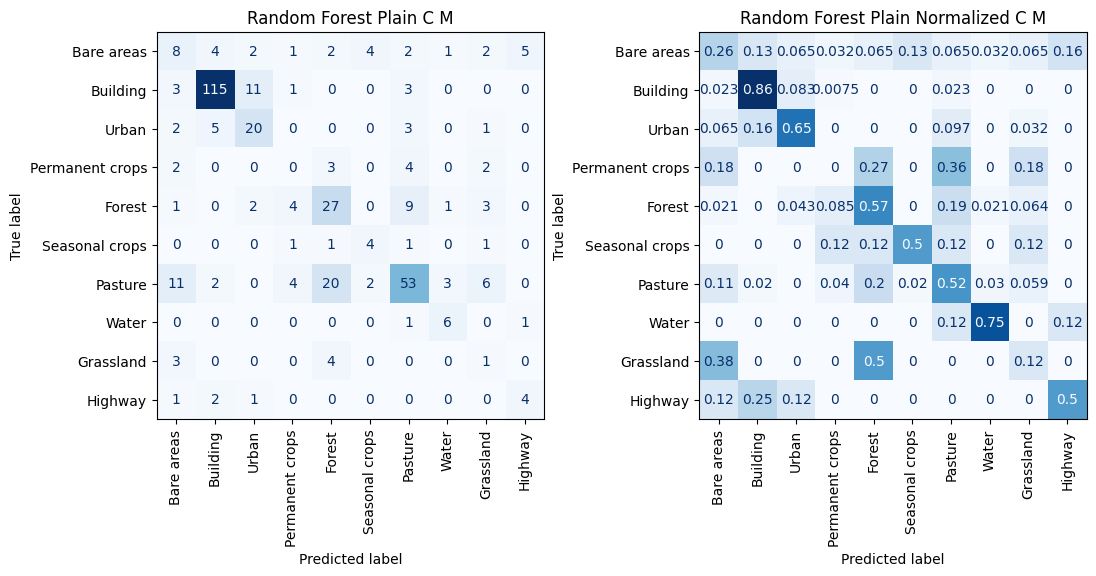

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.48359910862497324
best f1 val score 0.48359910862497324
best f1 train score 0.8391544286172274
f1-macro-avg-test: 0.44582074904606006

RF with SMOTE
Fitting 5 folds for each of 6 candidates, totalling 30 fits


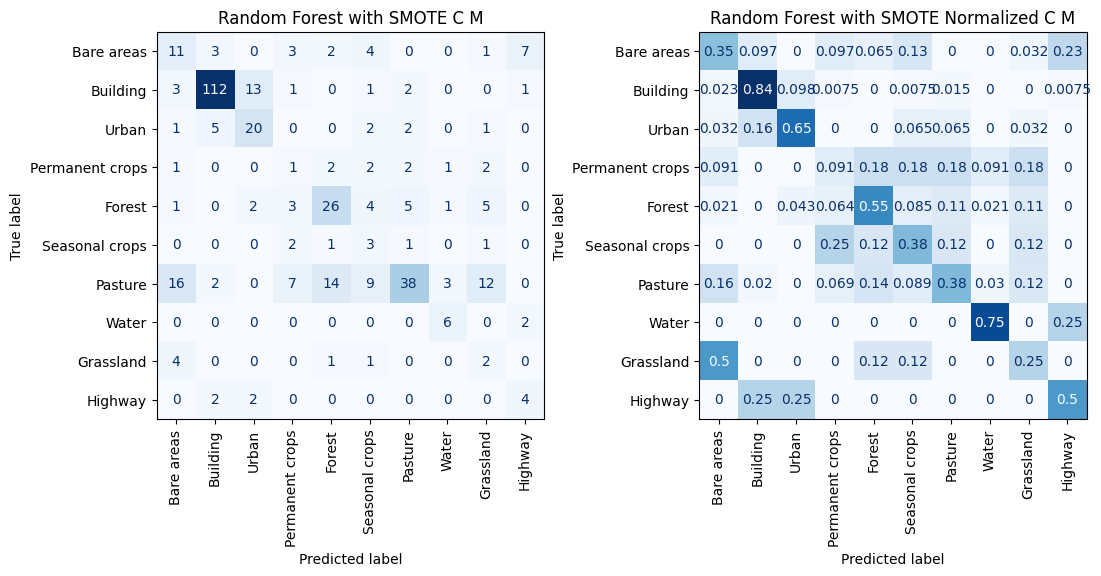

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.7693903871549089
best f1 val score 0.7693903871549089
best f1 train score 0.8584037202383836
f1-macro-avg-test: 0.4213925550514685

SVM Normal


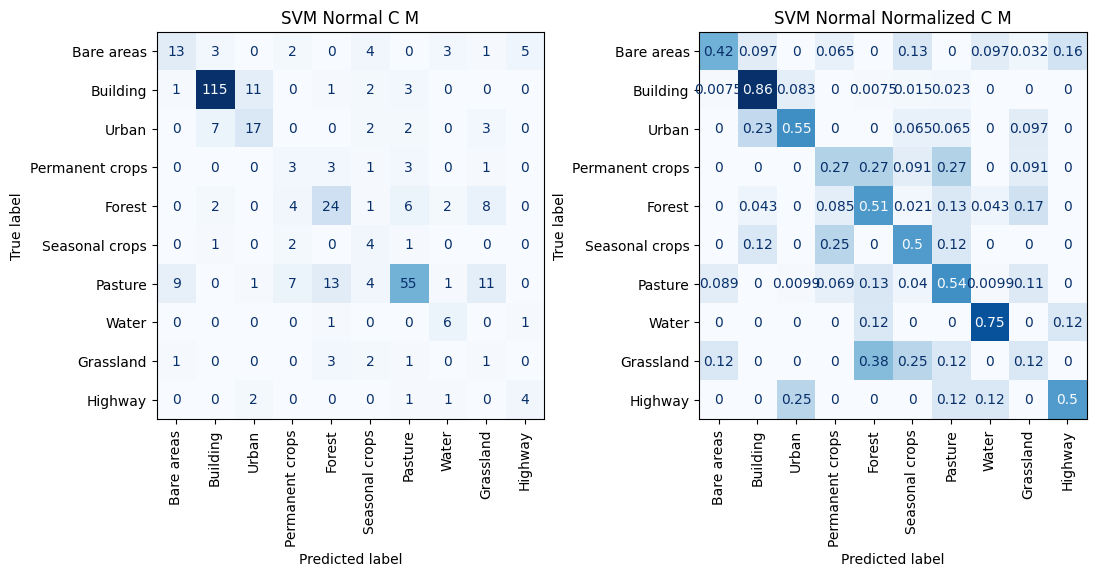

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.46089020728373997
best f1 val score 0.46089020728373997
best f1 train score 0.7109450237610642
f1-macro-avg-test: 0.4629007617782612

SVM with SMOTE


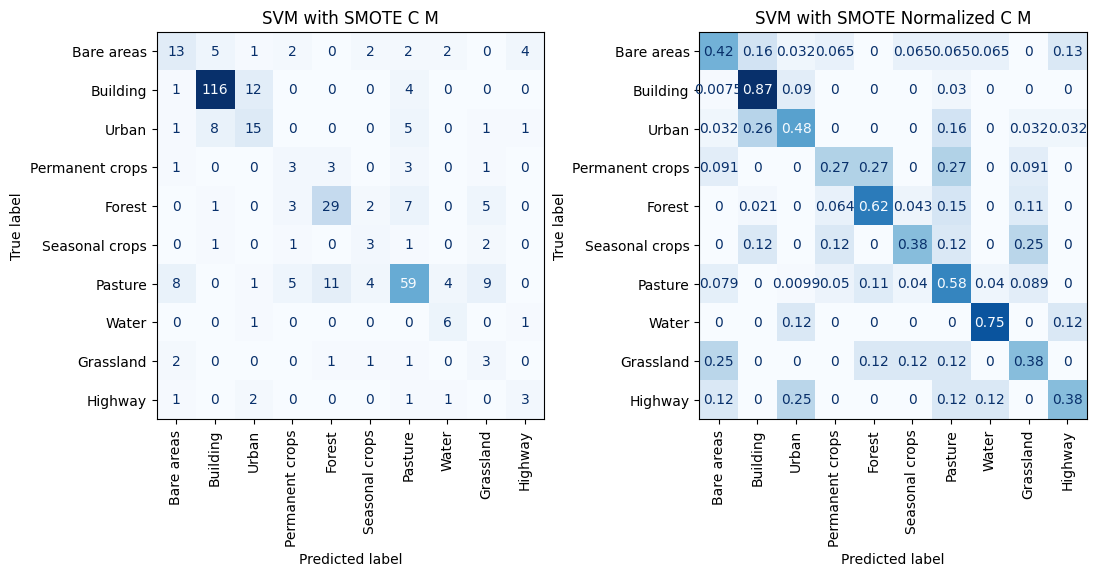

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.8630281059747338
best f1 val score 0.8630281059747338
best f1 train score 0.901547935913378
f1-macro-avg-test: 0.4753187501859342

Boruta Feature Selection
Selected features: ['r_mean', 'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var', 'b_mean', 'b_median', 'b_var', 'b_std', 'mean_intensity', 'perimeter', 'compactness', 'shape_index', 'area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']
Number of selected features: 20/22
Removed features: {'solidity', 'eccentricity'}

RF with SMOTE (Boruta)
Fitting 5 folds for each of 6 candidates, totalling 30 fits


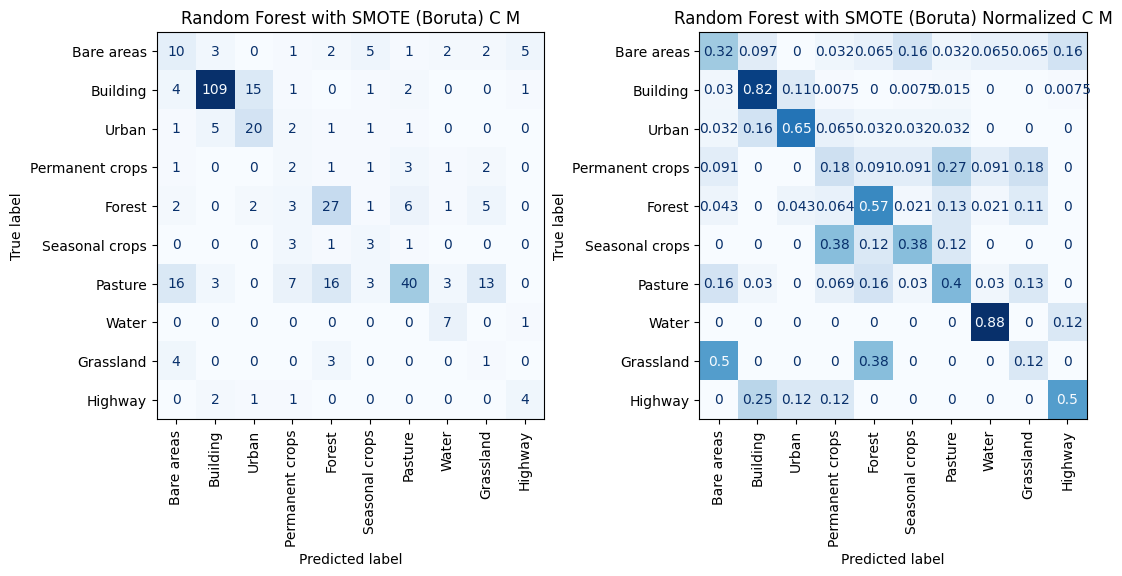

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.7727578672035099
best f1 val score 0.7727578672035099
best f1 train score 0.8585299732197498
f1-macro-avg-test: 0.43034508388536974


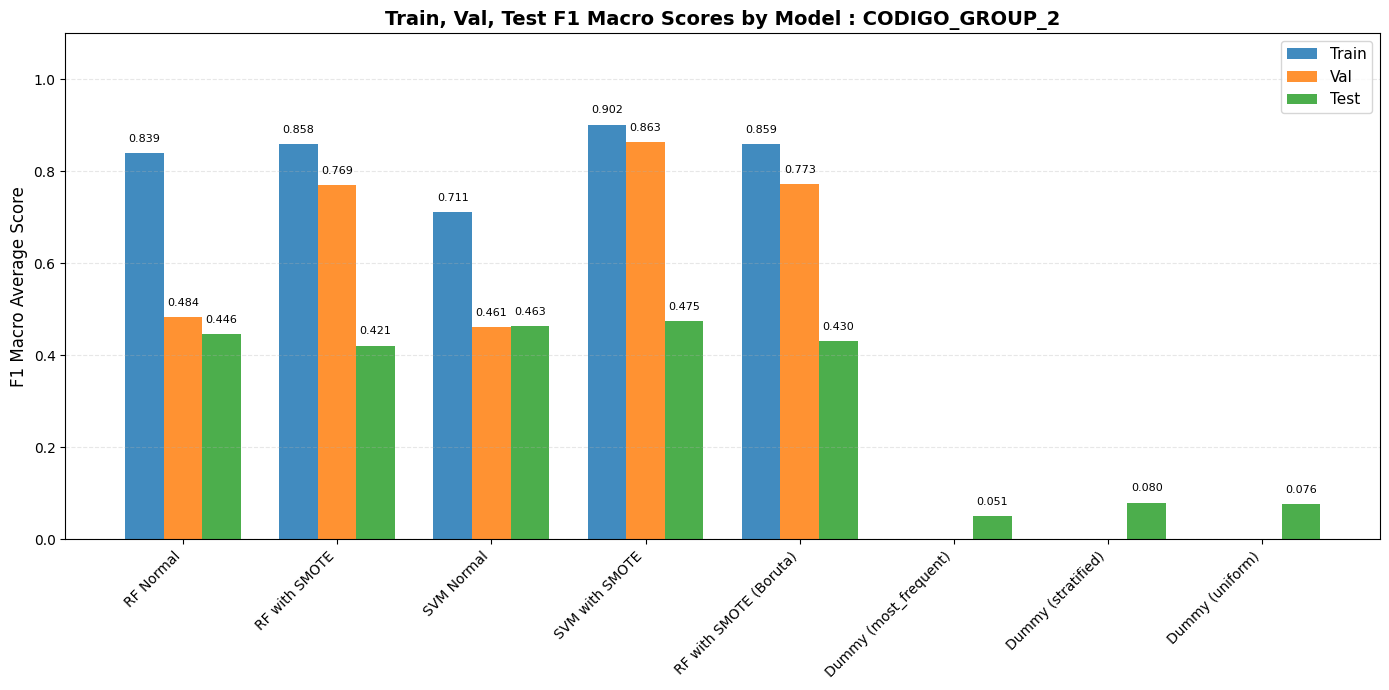

In [148]:
exp_group2 = Runner(gdf, 'CODIGO_GROUP_2', features)
exp_group2.load_train_test_data()
exp_group2.run_all_experiments(include_boruta=True)


RF Normal
Fitting 5 folds for each of 6 candidates, totalling 30 fits


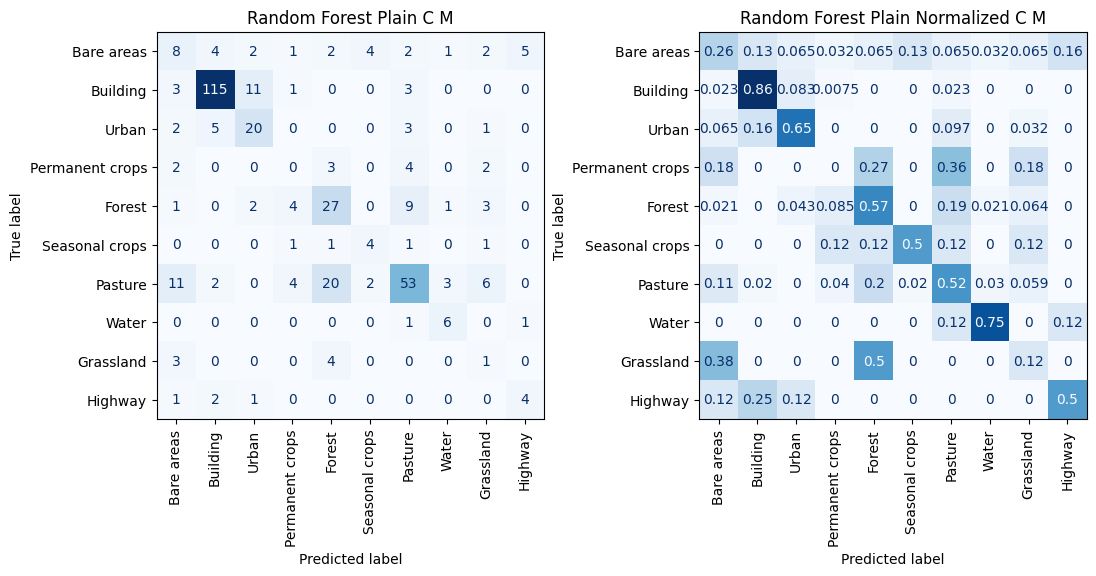

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.48359910862497324
best f1 val score 0.48359910862497324
best f1 train score 0.8391544286172274
f1-macro-avg-test: 0.44582074904606006


In [149]:
exp_group2.run_rf_normal()


RF with SMOTE
Fitting 5 folds for each of 6 candidates, totalling 30 fits


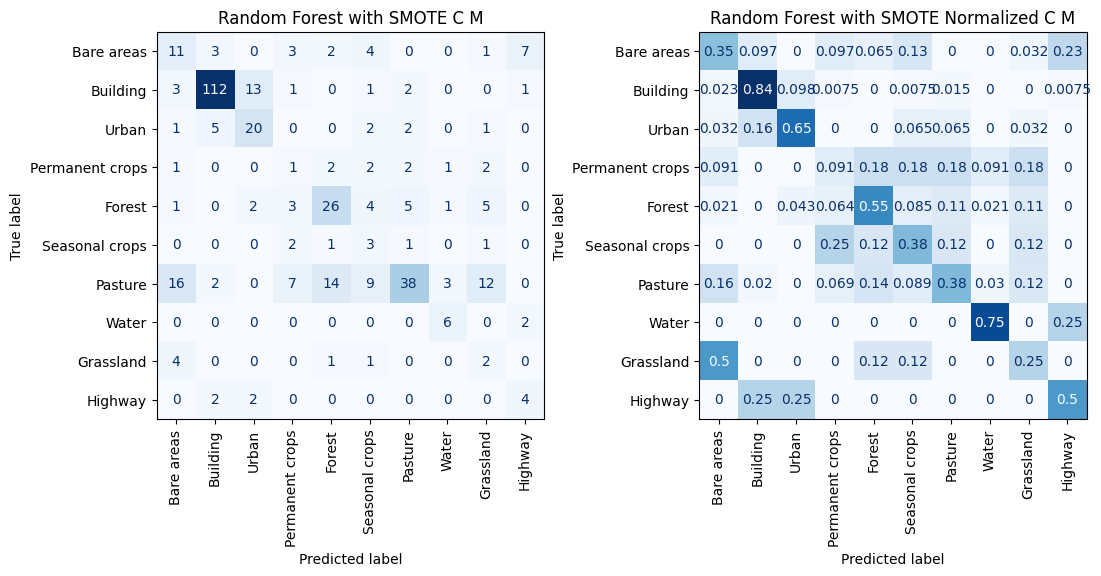

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.7693903871549089
best f1 val score 0.7693903871549089
best f1 train score 0.8584037202383836
f1-macro-avg-test: 0.4213925550514685


In [150]:
exp_group2.run_rf_with_smote()


SVM Normal


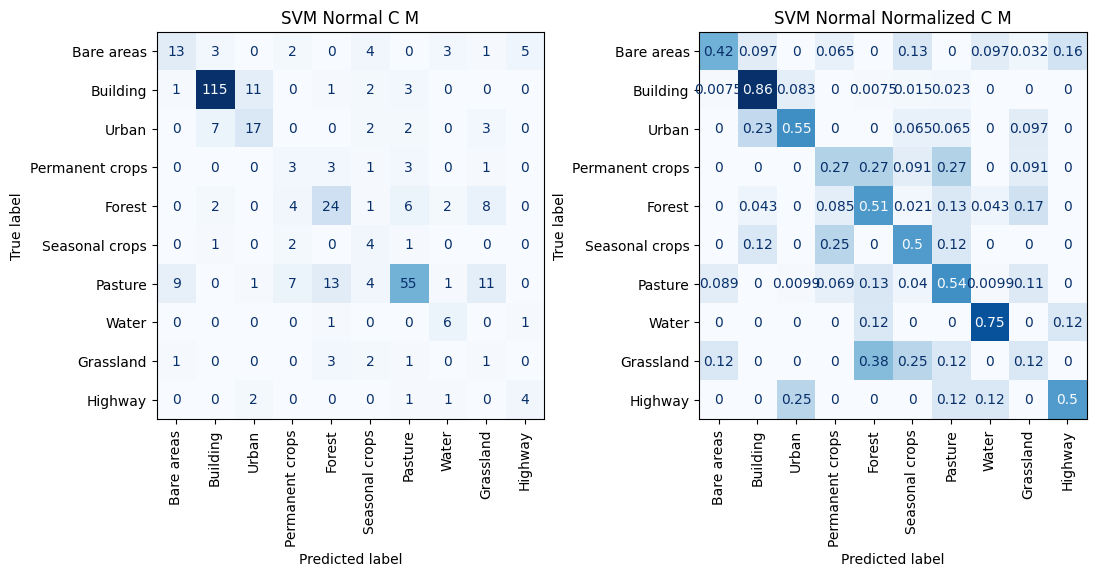

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.46089020728373997
best f1 val score 0.46089020728373997
best f1 train score 0.7109450237610642
f1-macro-avg-test: 0.4629007617782612


In [151]:
exp_group2.run_svm_normal()


SVM with SMOTE


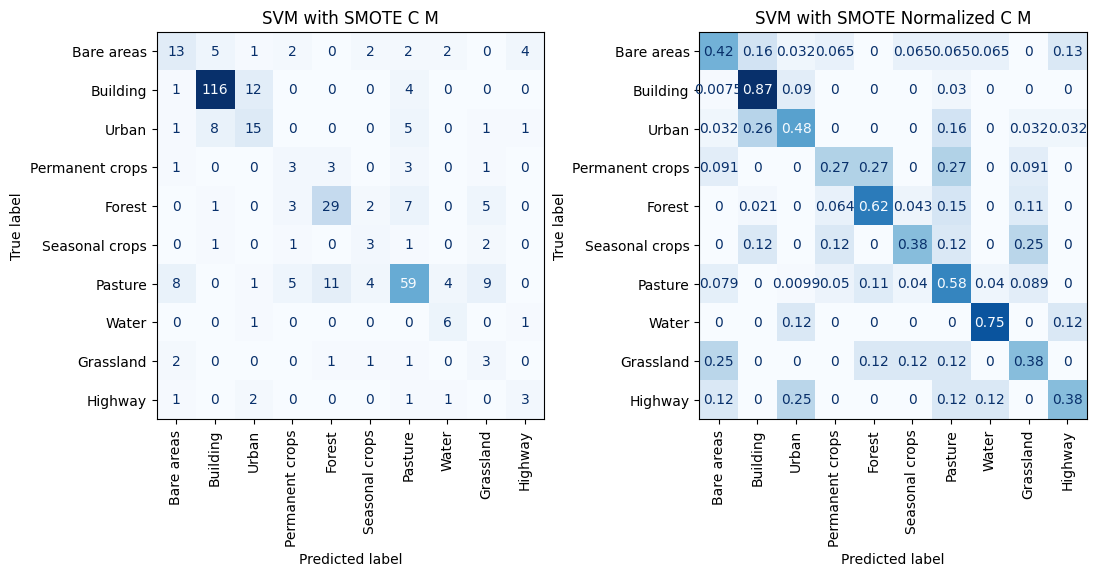

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.8630281059747338
best f1 val score 0.8630281059747338
best f1 train score 0.901547935913378
f1-macro-avg-test: 0.4753187501859342


In [152]:
exp_group2.run_svm_with_smote()

### Codigo Group 1 

train set distribution:
OBSERV_GROUP
Building               532
Agriculture            483
Forest                 342
Artificial Surfaces    154
Water                   32
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building               133
Agriculture            121
Forest                  85
Artificial Surfaces     39
Water                    8
Name: count, dtype: int64

RF Normal
Fitting 5 folds for each of 6 candidates, totalling 30 fits


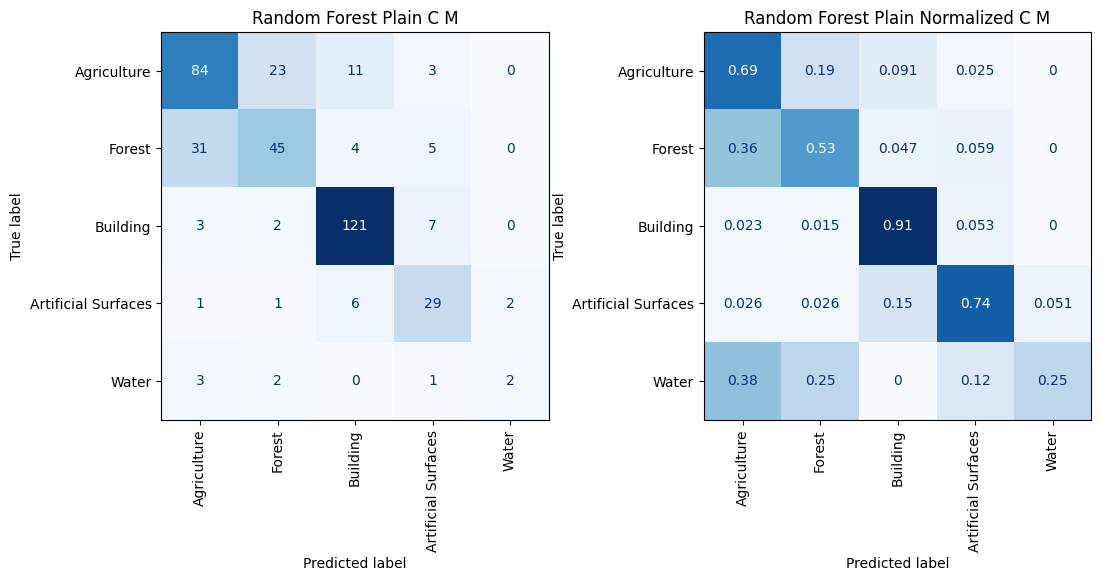

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.6848262841760102
best f1 val score 0.6848262841760102
best f1 train score 0.8827575160552572
f1-macro-avg-test: 0.6329575603330878

RF with SMOTE
Fitting 5 folds for each of 6 candidates, totalling 30 fits


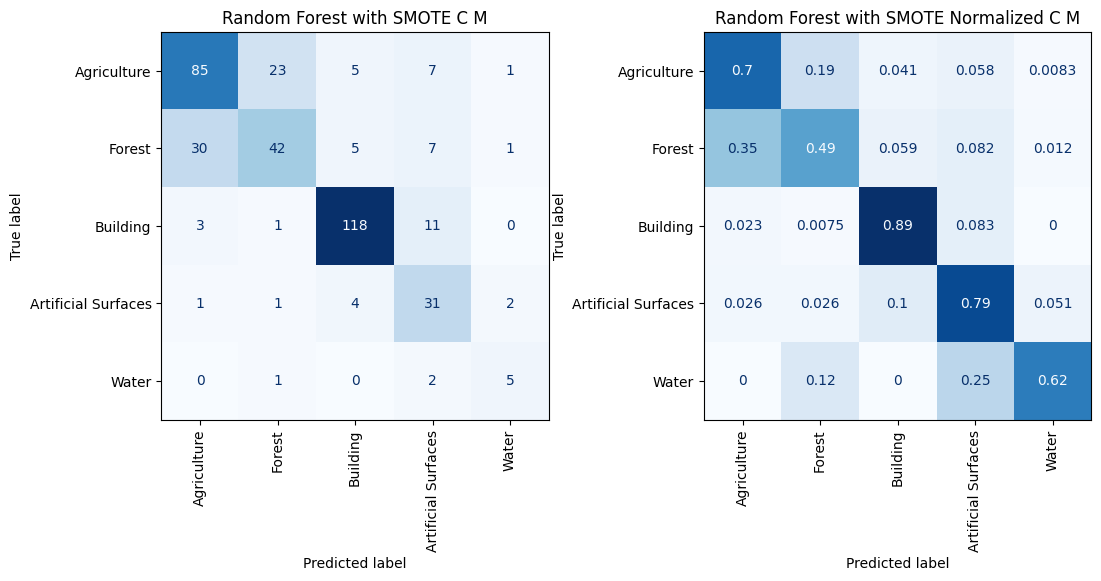

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 30}
Best f1 score: 0.7927698616418805
best f1 val score 0.7927698616418805
best f1 train score 0.899098108727177
f1-macro-avg-test: 0.675065906152385

SVM Normal


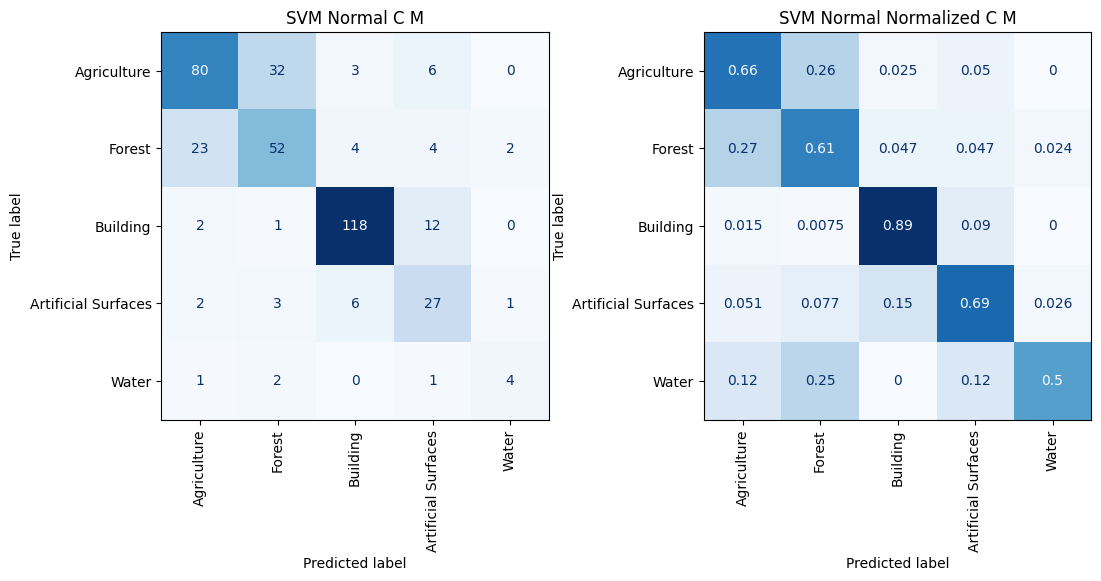

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.6621512685140288
best f1 val score 0.6621512685140288
best f1 train score 0.8186686228546725
f1-macro-avg-test: 0.6653979941848054

SVM with SMOTE


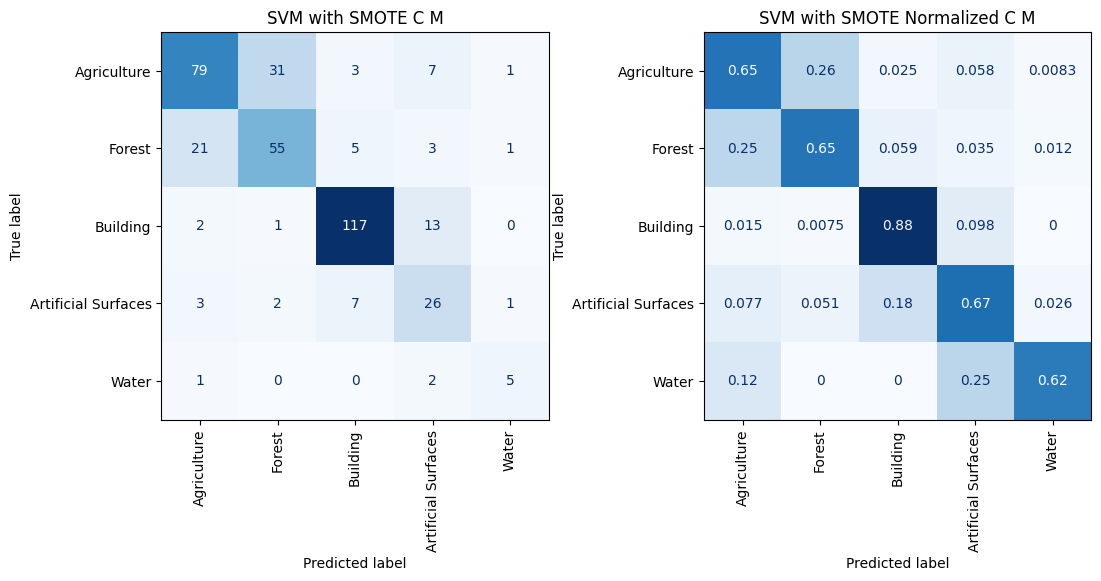

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.8139210781111453
best f1 val score 0.8139210781111453
best f1 train score 0.8739328403914308
f1-macro-avg-test: 0.6828031592078063

Boruta Feature Selection
Selected features: ['r_mean', 'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var', 'b_mean', 'b_median', 'b_var', 'b_std', 'eccentricity', 'mean_intensity', 'perimeter', 'compactness', 'shape_index', 'area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']
Number of selected features: 21/22
Removed features: {'solidity'}

RF with SMOTE (Boruta)
Fitting 5 folds for each of 6 candidates, totalling 30 fits


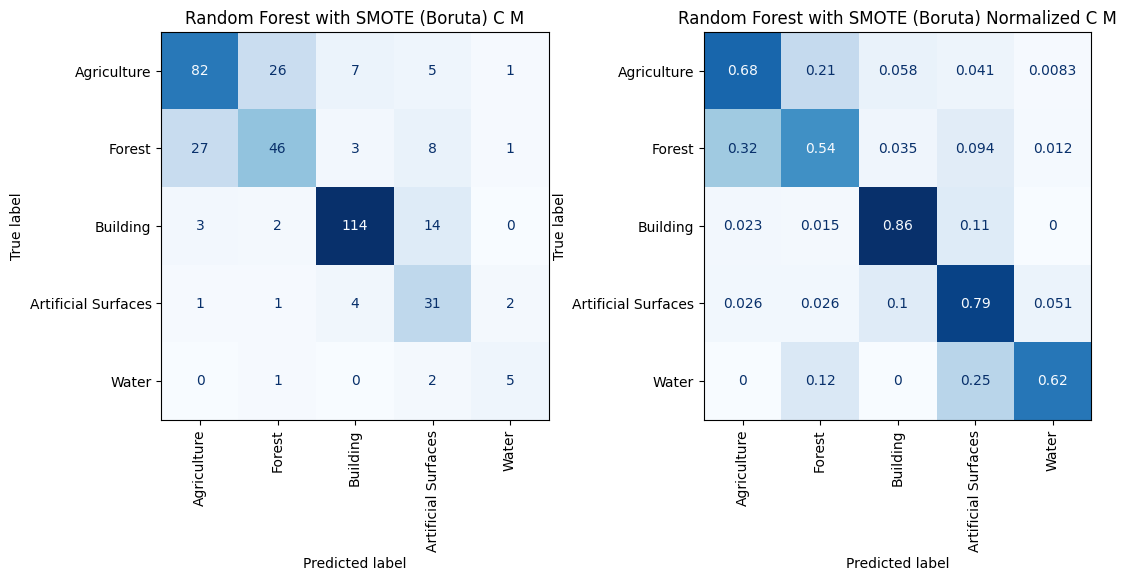

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.7933249382160316
best f1 val score 0.7933249382160316
best f1 train score 0.9003292491403908
f1-macro-avg-test: 0.6720688822108701


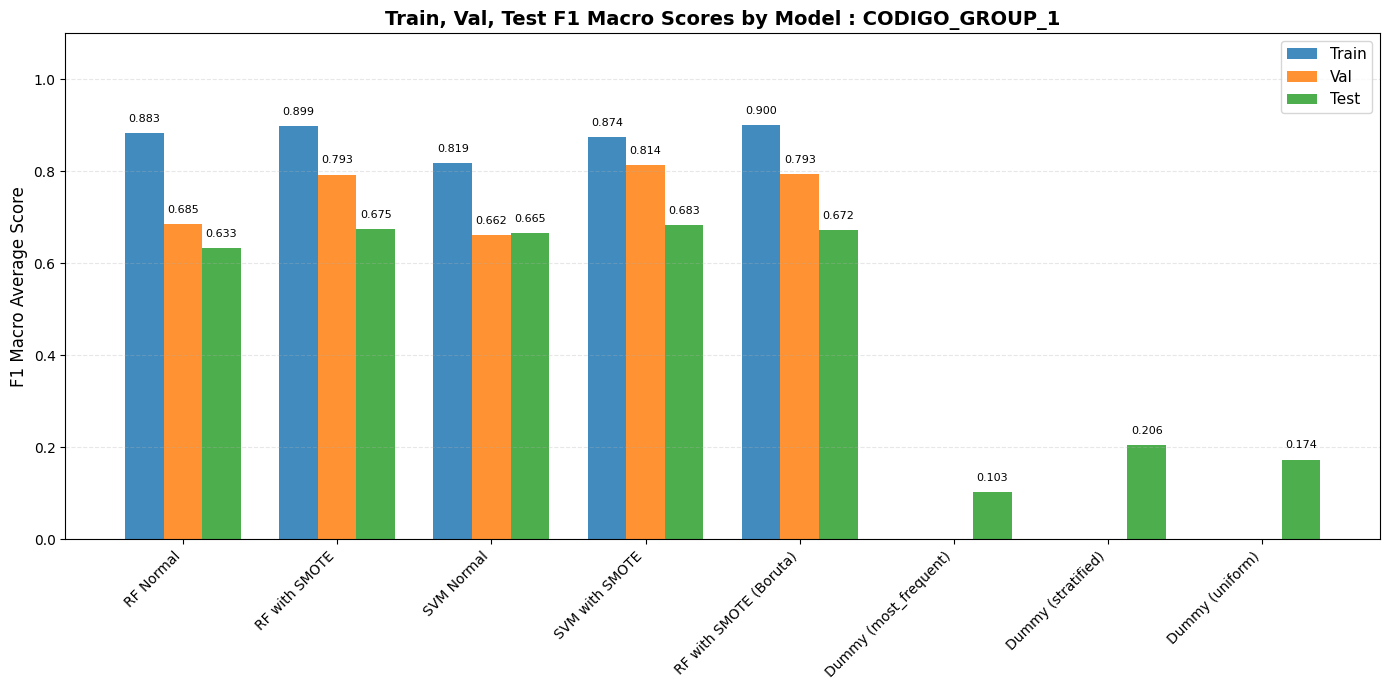

In [153]:
exp_group1 = Runner(gdf, 'CODIGO_GROUP_1', features)
exp_group1.load_train_test_data()
exp_group1.run_all_experiments(include_boruta=True)


RF Normal
Fitting 5 folds for each of 6 candidates, totalling 30 fits


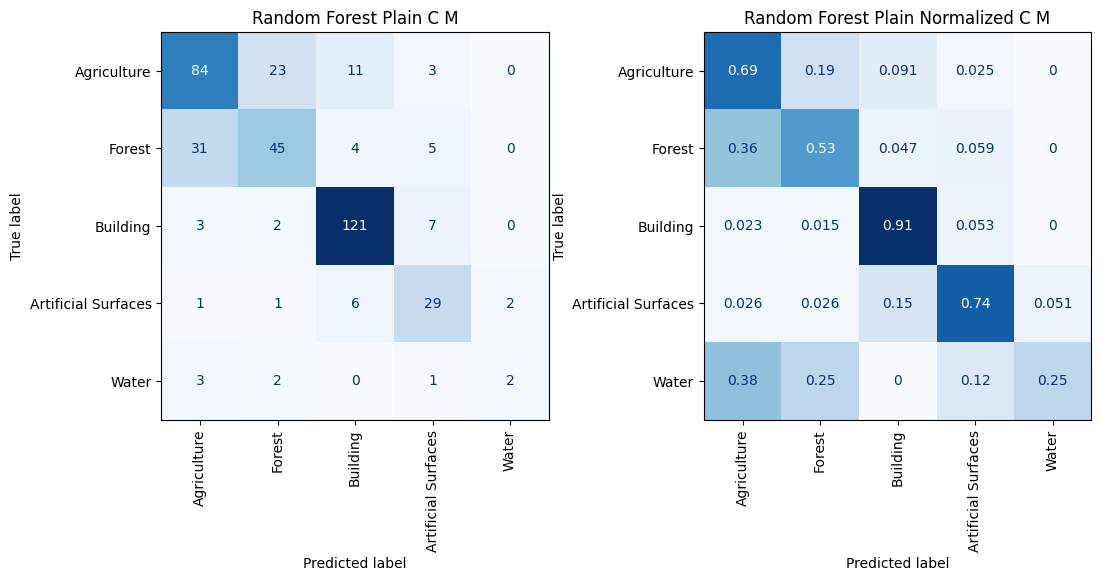

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best f1 score: 0.6848262841760102
best f1 val score 0.6848262841760102
best f1 train score 0.8827575160552572
f1-macro-avg-test: 0.6329575603330878


In [154]:
exp_group1.run_rf_normal()


RF with SMOTE
Fitting 5 folds for each of 6 candidates, totalling 30 fits


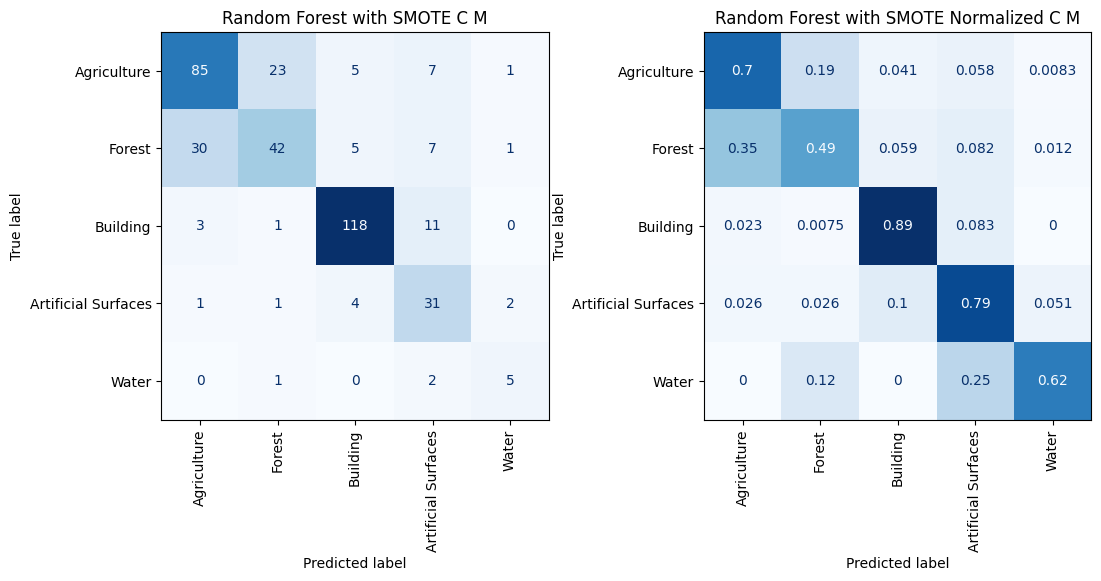

Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 9, 'max_leaf_nodes': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 30}
Best f1 score: 0.7927698616418805
best f1 val score 0.7927698616418805
best f1 train score 0.899098108727177
f1-macro-avg-test: 0.675065906152385


In [155]:
exp_group1.run_rf_with_smote()


SVM Normal


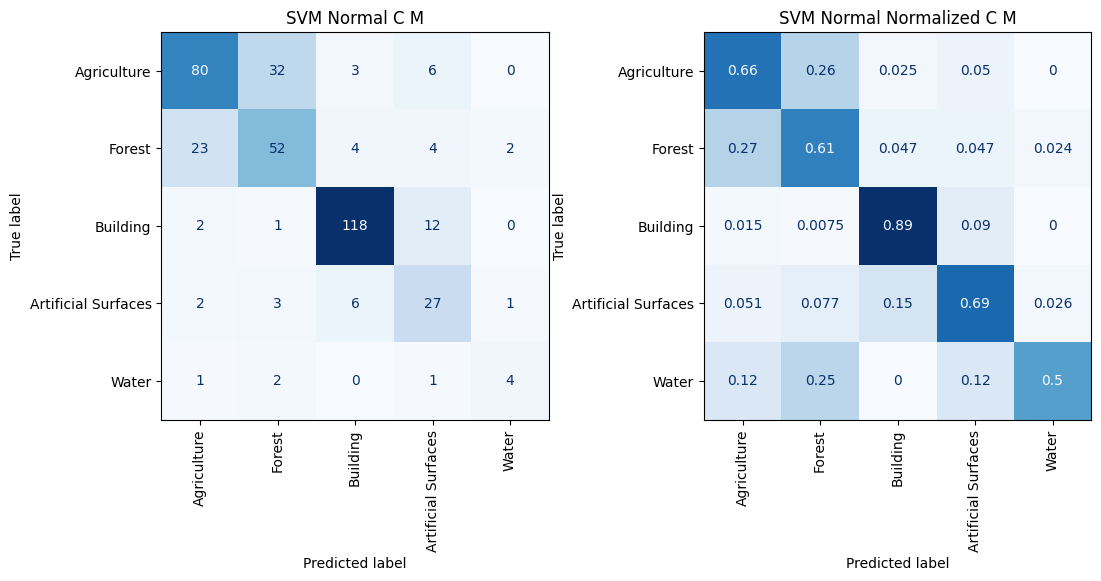

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.6621512685140288
best f1 val score 0.6621512685140288
best f1 train score 0.8186686228546725
f1-macro-avg-test: 0.6653979941848054


In [156]:
exp_group1.run_svm_normal()


SVM with SMOTE


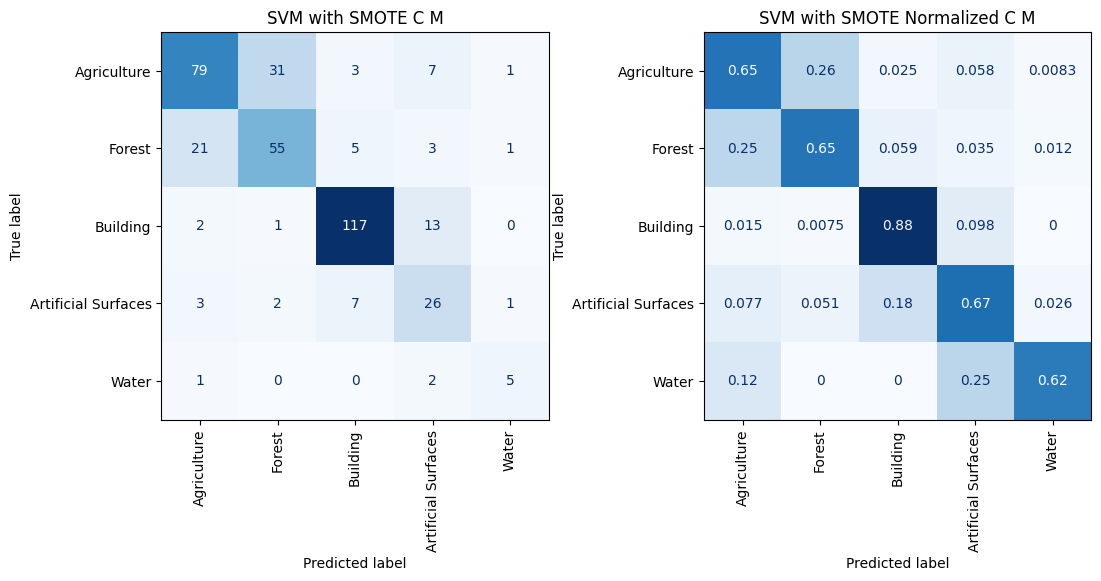

Best Hyperparameters: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Best f1 score: 0.8139210781111453
best f1 val score 0.8139210781111453
best f1 train score 0.8739328403914308
f1-macro-avg-test: 0.6828031592078063


In [157]:
exp_group1.run_svm_with_smote()